In [3]:
# Googleドライブのマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# パスを確認する
import os
os.listdir("/content/drive/MyDrive/employee-analytics-portfolio/data")

['WA_Fn-UseC_-HR-Employee-Attrition.csv']

In [5]:
# CSVファイルを読み込む
import pandas as pd
employee_df = pd.read_csv("/content/drive/MyDrive/employee-analytics-portfolio/data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# データの行数および列数を確認する
employee_df.shape

(1470, 35)

In [7]:
# 35項目を確認する
for i, column in enumerate(employee_df.columns):
  print(i, column)

0 Age
1 Attrition
2 BusinessTravel
3 DailyRate
4 Department
5 DistanceFromHome
6 Education
7 EducationField
8 EmployeeCount
9 EmployeeNumber
10 EnvironmentSatisfaction
11 Gender
12 HourlyRate
13 JobInvolvement
14 JobLevel
15 JobRole
16 JobSatisfaction
17 MaritalStatus
18 MonthlyIncome
19 MonthlyRate
20 NumCompaniesWorked
21 Over18
22 OverTime
23 PercentSalaryHike
24 PerformanceRating
25 RelationshipSatisfaction
26 StandardHours
27 StockOptionLevel
28 TotalWorkingYears
29 TrainingTimesLastYear
30 WorkLifeBalance
31 YearsAtCompany
32 YearsInCurrentRole
33 YearsSinceLastPromotion
34 YearsWithCurrManager


In [8]:
# データ型と欠損値を確認
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
# 欠損値を確認
employee_df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [10]:
# 退職者数を確認する
employee_df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [11]:
# 退職割合を確認する
employee_df["Attrition"].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [12]:
# 「退職した人」と「退職していない人」で年齢に違いがあるのか確認する
employee_df.groupby("Attrition")["Age"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Attrition,,,,,
No,1233,37.561233,36.0,18,60
Yes,237,33.607595,32.0,18,58


上の結果より、退職者の年齢が在籍者と比較して若い傾向があることがうかがえる

# 年代別の離職率を調べる

In [13]:
# 年代別にラベリングする
employee_df["AgeGroup"] = pd.cut(
    employee_df["Age"],
    bins = [0, 29, 39, 49, 59, 100],
    labels = ["20代", "30代", "40代", "50代", "60代"]
)

In [14]:
age_attrition = pd.crosstab(
    employee_df["AgeGroup"],
    employee_df["Attrition"],
    normalize="index"
) * 100

age_attrition

Attrition,No,Yes
AgeGroup,,
20代,72.085890,27.914110
30代,85.691318,14.308682
40代,90.257880,9.742120
50代,86.309524,13.690476
60代,100.000000,0.000000


In [15]:
# 年代別の人数を確認する
employee_df["AgeGroup"].value_counts().sort_index()

,count
AgeGroup,
20代,326
30代,622
40代,349
50代,168
60代,5


In [16]:
# 退職者の勤続年数を確認する
employee_df.groupby("Attrition")["YearsAtCompany"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Attrition,,,,,
No,1233,7.369019,6.0,0,37
Yes,237,5.130802,3.0,0,40


年代別の人数および退職者の勤続年数より、30代は従業員数が最も多く、離職率も50代と同程度のため、退職者数では30代が大きな割合を占めることが確認できた。

In [17]:
# 退職者に絞って年代別の勤続年数を確認する
employee_df[employee_df["Attrition"] == "Yes"].groupby("AgeGroup")["YearsAtCompany"].agg(
    ["count", "mean", "median", "min", "max"]
)

/tmp/ipykernel_6669/4032860081.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employee_df[employee_df["Attrition"] == "Yes"].groupby("AgeGroup")["YearsAtCompany"].agg(


,count,mean,median,min,max
AgeGroup,,,,,
20代,91,2.824176,2.0,0.0,11.0
30代,89,5.056180,4.0,0.0,18.0
40代,34,7.676471,6.0,1.0,24.0
50代,23,10.782609,6.0,0.0,40.0
60代,0,NaN,NaN,NaN,NaN


20代の退職者は平均勤続年数が2.8年、30代では5.1年であり、若年層ほど比較的早期に退職している傾向が確認された。  

50代の退職者は平均勤続年数が10.8年と長い一方、中央値は6年であり、一部の長期勤続者が平均を押し上げている可能性がある。

# 職位別の離職率を調べる

In [18]:
# 職位ごとの退職者数を確認する
employee_df.groupby("JobLevel")["Attrition"].value_counts()

JobLevel  Attrition
1         No           400
          Yes          143
2         No           482
          Yes           52
3         No           186
          Yes           32
4         No           101
          Yes            5
5         No            64
          Yes            5
Name: count, dtype: int64

In [19]:
# 職位ごとの離職率を確認する
joblevel_attriton = pd.crosstab(
    employee_df["JobLevel"],
    employee_df["Attrition"],
    normalize="index"
) * 100

joblevel_attriton

Attrition,No,Yes
JobLevel,,
1,73.664825,26.335175
2,90.262172,9.737828
3,85.321101,14.678899
4,95.283019,4.716981
5,92.753623,7.246377


In [20]:
# 年代および職位ごとに離職率を調べる
age_joblevel_attrition = pd.crosstab(
    [employee_df["AgeGroup"], employee_df["JobLevel"]],
    employee_df["Attrition"],
    normalize="index"
) * 100

age_joblevel_attrition

Attrition                  No        Yes
AgeGroup JobLevel                       
20代      1          64.888889  35.111111
         2          90.804598   9.195402
         3          69.230769  30.769231
         4         100.000000   0.000000
30代      1          79.166667  20.833333
         2          89.122807  10.877193
         3          88.888889  11.111111
         4          90.000000  10.000000
         5         100.000000   0.000000
40代      1          83.783784  16.216216
         2          93.700787   6.299213
         3          85.714286  14.285714
         4          93.750000   6.250000
         5          94.594595   5.405405
50代      1          75.000000  25.000000
         2          84.848485  15.151515
         3          78.125000  21.875000
         4          97.872340   2.127660
         5          89.285714  10.714286
60代      2         100.000000   0.000000
         3         100.000000   0.000000
         5         100.000000   0.000000

JobLevel 1は年代を問わず離職率が高い傾向が見られた。一方、JobLevel 2～5では年代によって離職率の順位が異なり、JobLevelと離職率の関係は単純な直線的関係ではないことが確認された。

In [21]:
# 年代ごとに職位の人数構成を調べる
age_joblevel_count = pd.crosstab(
    employee_df["AgeGroup"],
    employee_df["JobLevel"]
)

age_joblevel_count

JobLevel,1,2,3,4,5
AgeGroup,,,,,
20代,225,87,13,1,0
30代,216,285,108,10,3
40代,74,127,63,48,37
50代,28,33,32,47,28
60代,0,2,2,0,1


In [22]:
# 職位別に勤続年数を比較する
employee_df.groupby("JobLevel")["YearsAtCompany"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
JobLevel,,,,,
1,543,3.931860,3.0,0,20
2,534,6.752809,6.0,0,20
3,218,9.380734,9.0,0,40
4,106,13.886792,12.5,1,37
5,69,15.130435,18.0,0,36


In [23]:
# 退職者だけに絞った職位別の勤続年数を比較する
employee_df[employee_df["Attrition"] == "Yes"].groupby("JobLevel")["YearsAtCompany"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
JobLevel,,,,,
1,143,3.083916,2.0,0,17
2,52,5.250000,5.0,0,15
3,32,9.562500,8.5,0,40
4,5,16.400000,19.0,1,23
5,5,22.800000,24.0,5,32


###


今回の結果について
*  JobLevelが上がるにつれて、勤続年数も長くなる傾向がある
*  今回確認した退職者237人のうち、143人 / 237人 ≒ 60.3%がJobLevel 1

つまり、退職者の約6割がJobLevel 1といえる。





JobLevel 1は、
- 従業員：543人
- 退職者：143人
- 離職率：26.3%

だった。
一方、JobLevel 3は、
- 従業員：218人
- 退職者：32人
- 離職率：14.7%

だった。  
つまり、「離職率が高い」ことと「退職者数が多い」ことは別物といえ、JobLevel 1は両方とも高いことが確認された。

# 現時点で見えてきた退職者像

1.   年齢  
20代の離職率が 27.9% と最も高い。
2.   職位  
JobLevel 1の離職率が 26.3% と高い。  
3.   年齢 × JobLevel  
20代 × JobLevel 1では、離職率が 35.1%。
4.   勤続年数  
JobLevel 1の退職者は、平均勤続年数 3.08年、中央値 2年。  
そしてJobLevel 1は退職者全体の約6割を占めている。






まとめると、このデータでは、若年層、特にJobLevel 1の従業員で離職が多く、JobLevel 1の退職者は入社後比較的早い段階で退職している傾向が見られる。

# 退職と給与の関係を調べる

In [24]:
# 退職者および在籍者の月収を比較する
employee_df.groupby("Attrition")["MonthlyIncome"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Attrition,,,,,
No,1233,6832.739659,5204.0,1051,19999
Yes,237,4787.092827,3202.0,1009,19859


In [25]:
# JovLevel1に限定して比較する
employee_df[employee_df["JobLevel"] == 1].groupby("Attrition")["MonthlyIncome"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Attrition,,,,,
No,400,2854.407500,2719.0,1051,4968
Yes,143,2598.125874,2437.0,1009,4963


全体では退職者の給与が大幅に低いように見えるが、JobLevel 1だけに限定すると、その差は約256まで縮小する。  
「退職者の給与が低い」という結果の一部は、退職者にJobLevel 1の人が多いことによって生じている可能性がある。

# 退職と残業の関係を調べる

In [26]:
# 残業の有無による退職の割合を比較する
employee_df.groupby("OverTime")["Attrition"].value_counts(normalize=True) * 100

OverTime  Attrition
No        No           89.563567
          Yes          10.436433
Yes       No           69.471154
          Yes          30.528846
Name: proportion, dtype: float64

In [27]:
overtime_attrition = pd.crosstab(
    employee_df["OverTime"],
    employee_df["Attrition"],
    normalize="index"
) * 100

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


残業ありの従業員は、残業なしと比べて離職率が約20ポイント高い。  
また、比率で見ると、  

> 30.5 ÷ 10.4 ≒ 2.9

なので、残業ありの従業員は、残業なしの従業員と比較して約2.9倍の離職率となっている。

# 20代 × JobLevel 1 × 残業ありの離職率を調べる

In [28]:
# 職位および在籍有無ごとの離職率を調べる
joblevel_overtime_attrition = pd.crosstab(
    [employee_df["JobLevel"], employee_df["OverTime"]],
    employee_df["Attrition"],
    normalize="index"
) * 100

joblevel_overtime_attrition

Attrition                 No        Yes
JobLevel OverTime                      
1        No        84.237726  15.762274
         Yes       47.435897  52.564103
2        No        93.298969   6.701031
         Yes       82.191781  17.808219
3        No        87.741935  12.258065
         Yes       79.365079  20.634921
4        No        97.260274   2.739726
         Yes       90.909091   9.090909
5        No        96.078431   3.921569
         Yes       83.333333  16.666667

JobLevel1かつ残業ありの従業員における離職率が52.6%ということが確認できた。

In [29]:
# 職位と残業有無を比較する
joblevel_overtime_count = pd.crosstab(
    employee_df["JobLevel"],
    employee_df["OverTime"]
)

joblevel_overtime_count

OverTime,No,Yes
JobLevel,,
1,387,156
2,388,146
3,155,63
4,73,33
5,51,18


In [30]:
# 退職状況と残業有無を比較する
joblevel_overtime_attriton_count = pd.crosstab(
    [employee_df["JobLevel"],employee_df["OverTime"]],
    employee_df["Attrition"]
)

joblevel_overtime_attriton_count

Attrition           No  Yes
JobLevel OverTime          
1        No        326   61
         Yes        74   82
2        No        362   26
         Yes       120   26
3        No        136   19
         Yes        50   13
4        No         71    2
         Yes        30    3
5        No         49    2
         Yes        15    3

JobLevel 1について、
- 残業なし：387人中61人が退職 → 15.8%
- 残業あり：156人中82人が退職 → 52.6%  
ということが確認できた。  
つまり、JobLevel 1では156人という一定数の従業員が残業ありに該当し、そのうち82人が退職している。

In [31]:
# 年代の情報を追加して退職率を比較する
age_joblevel_overtime = pd.crosstab(
    [
        employee_df["AgeGroup"],
        employee_df["JobLevel"],
        employee_df["OverTime"]
    ],
    employee_df["Attrition"],
    normalize="index"
) * 100

age_joblevel_overtime

Attrition                           No        Yes
AgeGroup JobLevel OverTime                       
20代      1        No         78.481013  21.518987
                  Yes        32.835821  67.164179
         2        No         93.548387   6.451613
                  Yes        84.000000  16.000000
         3        No         72.727273  27.272727
                  Yes        50.000000  50.000000
         4        No        100.000000   0.000000
30代      1        No         86.875000  13.125000
                  Yes        57.142857  42.857143
         2        No         93.364929   6.635071
                  Yes        77.027027  22.972973
         3        No         91.025641   8.974359
                  Yes        83.333333  16.666667
         4        No         87.500000  12.500000
                  Yes       100.000000   0.000000
         5        No        100.000000   0.000000
                  Yes       100.000000   0.000000
40代      1        No         93.877551   6.122449
                  Yes        64.000000  36.000000
         2        No         94.565217   5.434783
                  Yes        91.428571   8.571429
         3        No         85.365854  14.634146
                  Yes        86.363636  13.636364
         4        No         97.058824   2.941176
                  Yes        85.714286  14.285714
         5        No         96.774194   3.225806
                  Yes        83.333333  16.666667
50代      1        No         85.000000  15.000000
                  Yes        50.000000  50.000000
         2        No         86.363636  13.636364
                  Yes        81.818182  18.181818
         3        No         86.956522  13.043478
                  Yes        55.555556  44.444444
         4        No        100.000000   0.000000
                  Yes        94.117647   5.882353
         5        No         94.117647   5.882353
                  Yes        81.818182  18.181818
60代      2        No        100.000000   0.000000
                  Yes       100.000000   0.000000
         3        No        100.000000   0.000000
         5        No        100.000000   0.000000

In [32]:
# 年代を追加して退職者数を比較する
age_joblevel_overtime_count = pd.crosstab(
    [employee_df["AgeGroup"],
     employee_df["JobLevel"],
     employee_df["OverTime"]
    ],
    employee_df["Attrition"]
)

age_joblevel_overtime_count

Attrition                    No  Yes
AgeGroup JobLevel OverTime          
20代      1        No        124   34
                  Yes        22   45
         2        No         58    4
                  Yes        21    4
         3        No          8    3
                  Yes         1    1
         4        No          1    0
30代      1        No        139   21
                  Yes        32   24
         2        No        197   14
                  Yes        57   17
         3        No         71    7
                  Yes        25    5
         4        No          7    1
                  Yes         2    0
         5        No          2    0
                  Yes         1    0
40代      1        No         46    3
                  Yes        16    9
         2        No         87    5
                  Yes        32    3
         3        No         35    6
                  Yes        19    3
         4        No         33    1
                  Yes        12    2
         5        No         30    1
                  Yes         5    1
50代      1        No         17    3
                  Yes         4    4
         2        No         19    3
                  Yes         9    2
         3        No         20    3
                  Yes         5    4
         4        No         30    0
                  Yes        16    1
         5        No         16    1
                  Yes         9    2
60代      2        No          1    0
                  Yes         1    0
         3        No          2    0
         5        No          1    0

# ここまでのデータから見える退職者像

### 退職者に多くみられる特徴  


1.   若年層  
20代の離職率が27.9%で最も高い。
2.   JobLevel 1  
離職率26.3%で、退職者237人のうち143人を占める。
3.   勤続年数が比較的短い  
JobLevel 1の退職者の平均勤続年数は3.1年、中央値2年。  
4.   残業あり  
残業ありの離職率は30.5%で、残業なしの10.4%の約2.9倍。
5.  特に「20代 × JobLevel 1 × 残業あり」  
67人中45人が退職し、離職率67.2%。



# 退職と職種の関係を調べる

In [33]:
# 職種ごとの退職者数を確認する
employee_df.groupby("JobRole")["Attrition"].value_counts()

JobRole                    Attrition
Healthcare Representative  No           122
                           Yes            9
Human Resources            No            40
                           Yes           12
Laboratory Technician      No           197
                           Yes           62
Manager                    No            97
                           Yes            5
Manufacturing Director     No           135
                           Yes           10
Research Director          No            78
                           Yes            2
Research Scientist         No           245
                           Yes           47
Sales Executive            No           269
                           Yes           57
Sales Representative       No            50
                           Yes           33
Name: count, dtype: int64

In [34]:
# 職種ごとの離職率を比較する
jobrole_attrition = pd.crosstab(
    employee_df["JobRole"],
    employee_df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


離職率ではSales Representative、退職者数ではLaboratory Technicianが最も高い。

In [35]:
# 職種と職位の人数構成を確認する
jobrole_joblevel_count = pd.crosstab(
    employee_df["JobRole"],
    employee_df["JobLevel"]
)

jobrole_joblevel_count

JobLevel,1,2,3,4,5
JobRole,,,,,
Healthcare Representative,0,78,44,9,0
Human Resources,33,13,6,0,0
Laboratory Technician,200,56,3,0,0
Manager,0,0,12,47,43
Manufacturing Director,0,90,45,10,0
Research Director,0,0,28,26,26
Research Scientist,234,57,1,0,0
Sales Executive,0,233,79,14,0
Sales Representative,76,7,0,0,0


In [36]:
# 職種および残業有無ごとの離職率を比較する
jobrole_overtime_attrition = pd.crosstab(
    [employee_df["JobRole"], employee_df["OverTime"]],
    employee_df["Attrition"],
    normalize="index"
) * 100

jobrole_overtime_attrition

Attrition                                  No        Yes
JobRole                   OverTime                      
Healthcare Representative No        92.553191   7.446809
                          Yes       94.594595   5.405405
Human Resources           No        82.051282  17.948718
                          Yes       61.538462  38.461538
Laboratory Technician     No        84.263959  15.736041
                          Yes       50.000000  50.000000
Manager                   No        98.666667   1.333333
                          Yes       85.185185  14.814815
Manufacturing Director    No        94.339623   5.660377
                          Yes       89.743590  10.256410
Research Director         No        98.245614   1.754386
                          Yes       95.652174   4.347826
Research Scientist        No        92.820513   7.179487
                          Yes       65.979381  34.020619
Sales Executive           No        88.793103  11.206897
                          Yes       67.021277  32.978723
Sales Representative      No        71.186441  28.813559
                          Yes       33.333333  66.666667

In [37]:
# 職種および残業有無ごとの退職者数を比較する
jobrole_overtime_count = pd.crosstab(
    [employee_df["JobRole"], employee_df["OverTime"]],
    employee_df["Attrition"]
)

jobrole_overtime_count

Attrition                            No  Yes
JobRole                   OverTime          
Healthcare Representative No         87    7
                          Yes        35    2
Human Resources           No         32    7
                          Yes         8    5
Laboratory Technician     No        166   31
                          Yes        31   31
Manager                   No         74    1
                          Yes        23    4
Manufacturing Director    No        100    6
                          Yes        35    4
Research Director         No         56    1
                          Yes        22    1
Research Scientist        No        181   14
                          Yes        64   33
Sales Executive           No        206   26
                          Yes        63   31
Sales Representative      No         42   17
                          Yes         8   16

退職者数だけを見ると残業の有無でほとんど差がないが、それぞれのグループに所属する人数を考慮すると、残業ありの従業員では非常に高い割合で退職が発生している。

職位について離職率が高かったSales Representativeについて着目すると、この職種は全体で83人在籍しており、うちJobLevel1の人数は76人である。  
よって、約91.6%がJobLevel1で構成されている。

したがって、Sales Representativeの高い離職率については、  


> 職種そのものだけではなく、JobLevel 1の従業員が非常に多いという職種構成や、残業との組み合わせが関係している可能性  

も考える必要がある。


また、Laboratory Technicianに注目してみると、  
残業なし：

197人中31人退職
離職率 15.7%

残業あり：

62人中31人退職
離職率 50.0%

つまり、  


> 残業ありでは2人に1人が退職  

していることがわかる。  
しかもSales Representativeより人数が多い。  

さらにJobLevelを見ると、

Level 1 → 200人
Level 2 → 56人
Level 3 → 3人

なので、こちらもJobLevel 1が非常に多い職種である。  
Sales Representativeだけの特殊な現象ではなさそうである。



# 退職と仕事の満足度の関係を調べる

In [38]:
#仕事満足度と離職率を比較する
jobsatisfaction_attrition = pd.crosstab(
    employee_df["JobSatisfaction"],
    employee_df["Attrition"],
    normalize="index"
) * 100

jobsatisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [39]:
# 仕事満足度と退職者数を比較する
jobsatisfaction_count = pd.crosstab(
    employee_df["JobSatisfaction"],
    employee_df["Attrition"]
)

jobsatisfaction_count

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


最低満足度のLevel 1では 22.8%、最高満足度のLevel 4では 11.3%であることから、JobSatisfaction 1と4では約11.5ポイント差がある。  
つまり、Level 1の離職率はLevel 4の約2倍である。  
このことから、仕事満足度が低いグループほど離職率が高い傾向が見られる。

# 退職と仕事満足度および残業の関係を調べる

In [40]:
# 仕事満足度および残業有無ごとの離職率を比較する
jobsatisfaction_overtime_attrition = pd.crosstab(
    [employee_df["JobSatisfaction"], employee_df["OverTime"]],
    employee_df["Attrition"],
    normalize="index"
) * 100

jobsatisfaction_overtime_attrition

Attrition                        No        Yes
JobSatisfaction OverTime                      
1               No        82.439024  17.560976
                Yes       64.285714  35.714286
2               No        90.521327   9.478673
                Yes       62.318841  37.681159
3               No        90.031153   9.968847
                Yes       66.115702  33.884298
4               No        93.059937   6.940063
                Yes       78.873239  21.126761

In [41]:
# 仕事満足度および残業有無ごとの退職者数を比較する
jobsatisfaction_overtime_count = pd.crosstab(
    [employee_df["JobSatisfaction"], employee_df["OverTime"]],
    employee_df["Attrition"]
)

jobsatisfaction_overtime_count

Attrition                  No  Yes
JobSatisfaction OverTime          
1               No        169   36
                Yes        54   30
2               No        191   20
                Yes        43   26
3               No        289   32
                Yes        80   41
4               No        295   22
                Yes       112   30

離職率だけ整理すると、  
| JobSatisfaction |  残業なし |      残業あり |       差 |
| --------------: | ----: | --------: | ------: |
|               1 | 17.6% | **35.7%** | +18.2pt |
|               2 |  9.5% | **37.7%** | +28.2pt |
|               3 | 10.0% | **33.9%** | +23.9pt |
|               4 |  6.9% | **21.1%** | +14.2pt |

すべての仕事満足度で、残業ありのほうが離職率が高いことが確認された。


特に着目したいのが、満足度が最高の4でも、  

*   残業なし → 6.9%
*   残業あり → 21.1%

と、約14.2ポイント上昇している。  
つまり、  


> 仕事への満足度が高い従業員でも、残業ありのグループでは離職率が高い  

という傾向が確認された。



以上から現時点では、仕事満足度だけで離職率の違いを説明するのは難しく、残業の有無が重要な要素として繰り返し現れていると考えられる。

# 離職率のグラフ作成

In [42]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 45.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=285645f0dcbb8a45ad6de565e22fcb2d3e9aba49f549d70ab9fb79cd26229944
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib


### 年代別の離職率

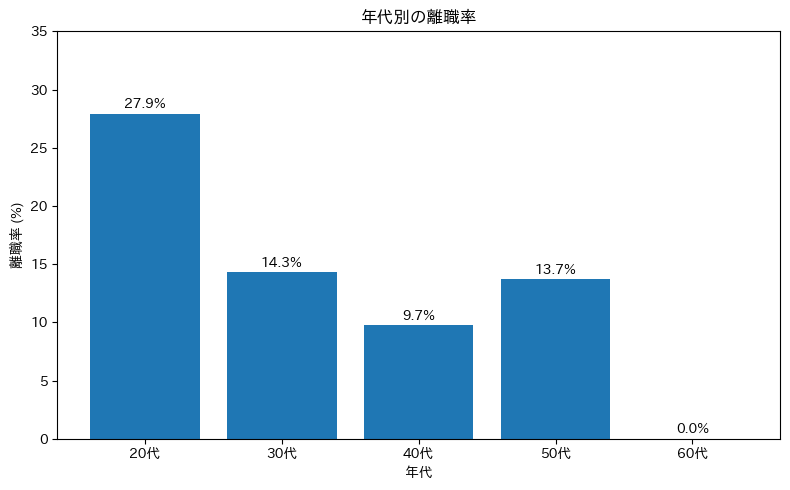

In [43]:
import matplotlib.pyplot as plt
import japanize_matplotlib

# 年代別の離職率を計算
age_attrition_rate = pd.crosstab(
    employee_df["AgeGroup"],
    employee_df["Attrition"],
    normalize="index"
)["Yes"] * 100

# グラフ作成
plt.figure(figsize=(8, 5))

plt.bar(
    age_attrition_rate.index.astype(str),
    age_attrition_rate.values
)

plt.title("年代別の離職率")
plt.xlabel("年代")
plt.ylabel("離職率 (%)")

# 各棒の上に数値を表示
for i, value in enumerate(age_attrition_rate.values):
   plt.text(i,
            value + 0.5,
            f"{value:.1f}%",
            ha="center")

plt.ylim(0, 35)
plt.tight_layout()

plt.savefig(
    "attrition_rate_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 職位別の離職率

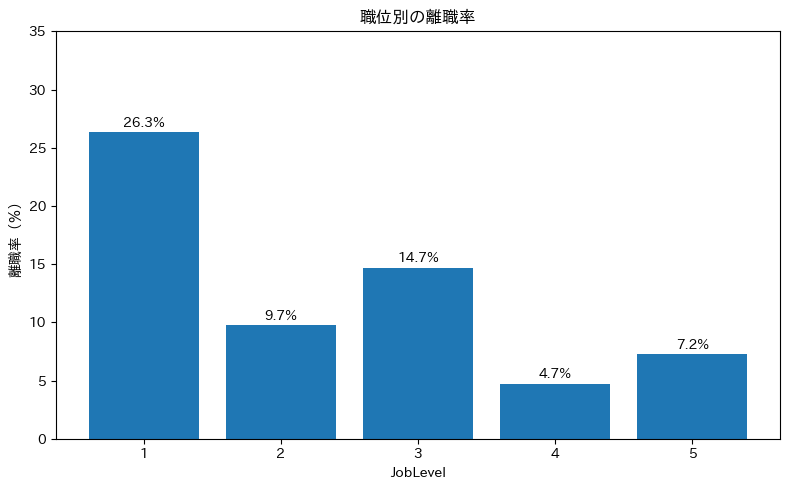

In [44]:
# 職位（JobLevel）別の離職率を計算
joblevel_attriton_rate = (
    pd.crosstab(
        employee_df["JobLevel"],
        employee_df["Attrition"],
        normalize="index"
    )["Yes"] * 100
)

# グラフ作成
plt.figure(figsize=(8, 5))

plt.bar(
    joblevel_attriton_rate.index.astype(str),
    joblevel_attriton_rate.values
)

plt.title("職位別の離職率")
plt.xlabel("JobLevel")
plt.ylabel("離職率（％）")

# 各棒の上に離職率を表示
for i, value in enumerate(joblevel_attriton_rate.values):
  plt.text(
      i,
      value + 0.5,
      f"{value:.1f}%",
      ha = "center"
  )

plt.ylim(0, 35)
plt.tight_layout()

plt.savefig(
    "attrition_rate_by_joblevel.png",
    dpi=300,
    bbox_inches="tight"
  )

plt.show()

### 職種別の離職率

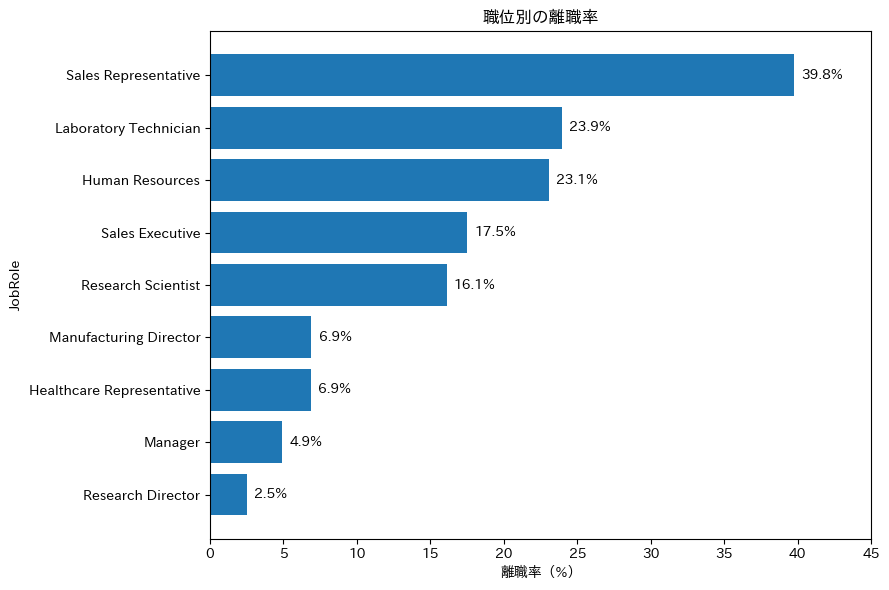

In [45]:
# 職位（JobRole）別の離職率を計算
jobrole_attrition_rate = (
    pd.crosstab(
        employee_df["JobRole"],
        employee_df["Attrition"],
        normalize="index"
    )["Yes"] * 100
)

# 離職率が高い順に並べる
jobrole_attrition_rate = jobrole_attrition_rate.sort_values(
    ascending=True
)

# グラフ作成
plt.figure(figsize=(9, 6))

plt.barh(
    jobrole_attrition_rate.index,
    jobrole_attrition_rate.values
)

plt.title("職位別の離職率")
plt.xlabel("離職率（%）")
plt.ylabel("JobRole")

# 各棒の右側に離職率を表示
for i, value in enumerate(jobrole_attrition_rate.values):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, 45)
plt.tight_layout()

plt.savefig(
    "attrition_rate_by_jobrole.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# 仕事満足度（JobSatisfaction） × 残業（OverTime）別の離職率を計算
jobsatisfaction_overtime_rate = (
    pd.crosstab(
        [employee_df["JobSatisfaction"], employee_df["OverTime"]],
        employee_df["Attrition"],
        normalize="index"
    )["Yes"] * 100
)

jobsatisfaction_overtime_rate

JobSatisfaction  OverTime
1                No          17.560976
                 Yes         35.714286
2                No           9.478673
                 Yes         37.681159
3                No           9.968847
                 Yes         33.884298
4                No           6.940063
                 Yes         21.126761
Name: Yes, dtype: float64

In [47]:
# グラフ用に表の形を変える
jobsatisfaction_overtime_plot = (
    jobsatisfaction_overtime_rate
    .unstack()
)

jobsatisfaction_overtime_plot

OverTime,No,Yes
JobSatisfaction,,
1,17.560976,35.714286
2,9.478673,37.681159
3,9.968847,33.884298
4,6.940063,21.126761


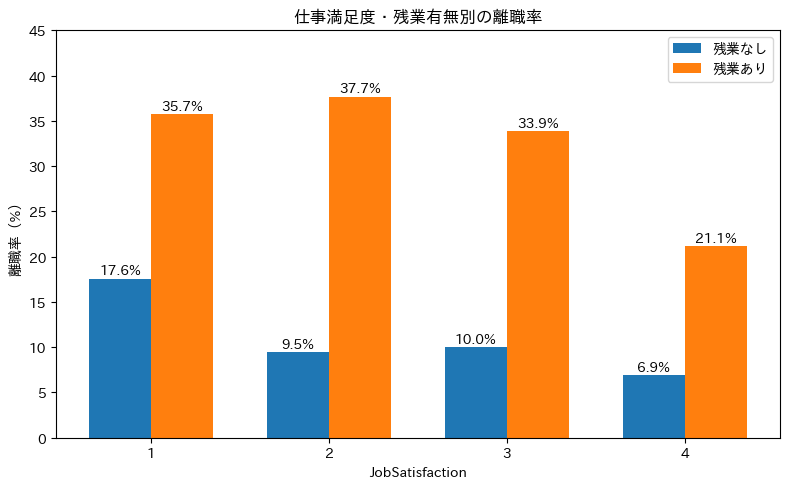

In [48]:
import numpy as np

# グラフを作成

x = np.arange(len(jobsatisfaction_overtime_plot.index))
width = 0.35

plt.figure(figsize=(8, 5))

# 残業なし
plt.bar(
    x - width / 2,
    jobsatisfaction_overtime_plot["No"],
    width,
    label="残業なし"
)

# 残業あり
plt.bar(
    x + width / 2,
    jobsatisfaction_overtime_plot["Yes"],
    width,
    label="残業あり"
)

plt.title("仕事満足度・残業有無別の離職率")
plt.xlabel("JobSatisfaction")
plt.ylabel("離職率（%）")

# x軸のラベルを設定
plt.xticks(
    x,
    jobsatisfaction_overtime_plot.index
)

# 棒の上に離職率を表示
for i, value in enumerate(jobsatisfaction_overtime_plot["No"]):
  plt.text(
      x[i] - width / 2,
      value + 0.5,
      f"{value:.1f}%",
      ha="center"
  )

for i, value in enumerate(jobsatisfaction_overtime_plot["Yes"]):
  plt.text(
      x[i] + width / 2,
      value + 0.5,
      f"{value:.1f}%",
      ha="center"
  )

plt.ylim(0, 45)
plt.legend()
plt.tight_layout()

plt.savefig(
    "attrition_rate_by_jobsatisfaction_overtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
import os

os.listdir("/content")

['.config',
 'attrition_rate_by_joblevel.png',
 'attrition_rate_by_jobsatisfaction_overtime.png',
 'attrition_rate_by_jobrole.png',
 'attrition_rate_by_age_group.png',
 'drive',
 'sample_data']